In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Seed set kar rahe hain taake data consistency rahe
np.random.seed(42)
random.seed(42)

# 1. Total rows define karte hain (Requirement: Minimum 1,000 records)
num_records = 1200  # Hum safe side rehne ke liye 1200 rows bana rahe hain

# 2. Realistic Data Lists (Pakistan ke context ke mutabiq commercial categories)
cities = ['Lahore', 'Karachi', 'Islamabad', 'Faisalabad', 'Rawalpindi', 'Multan']
payment_methods = ['Cash', 'Credit Card', 'Debit Card', 'EasyPaisa', 'JazzCash']

categories_products = {
    'Electronics': [('Smart Phone', 45000), ('Laptop', 85000), ('Bluetooth Speaker', 3500), ('Power Bank', 2500), ('Smart Watch', 6000)],
    'Clothing': [('T-Shirt', 1200), ('Jeans', 2200), ('Kurtas', 3000), ('Jacket', 4500), ('Socks Pack', 600)],
    'Groceries': [('Cooking Oil 5L', 2600), ('Basmati Rice 5kg', 1800), ('Sugar 5kg', 750), ('Tea Pack', 950), ('Milk Pack 1L', 290)],
    'Supermarket Sales': [('Shampoo', 850), ('Detergent Powder', 1400), ('Body Wash', 650), ('Toothpaste', 350), ('Dishwasher Liquid', 450)],
    'Restaurant Orders': [('Pizza Large', 1650), ('Burger Combo', 850), ('Biryani Platter', 600), ('Cold Drink 1.5L', 150), ('Molten Lava Cake', 450)]
}

# 3. Lists generate karne ka process
tx_ids = [f"TXN-{2026}{i:04d}" for i in range(1, num_records + 1)]
cust_ids = [f"CUST-{random.randint(1000, 2500)}" for _ in range(num_records)]

prod_categories = []
prod_names = []
unit_prices = []
quantities = []
total_amounts = []
purchase_dates = []
customer_cities = []
methods_used = []

# Date range define karte hain (Pichle 6 mahine ka data trends ke liye)
start_date = datetime(2026, 1, 1)

for i in range(num_records):
    # Random category aur product select karna
    category = random.choice(list(categories_products.keys()))
    product_info = random.choice(categories_products[category])
    product_name, base_price = product_info
    
    # Realistic fluctuations (Prices mein thoda random change)
    price = round(base_price * random.uniform(0.95, 1.05), 2)
    qty = random.randint(1, 5)
    total = round(price * qty, 2)
    
    # Dates distribute karna
    random_days = random.randint(0, 170)  # Jan se June ke darmiyan
    p_date = start_date + timedelta(days=random_days)
    
    # Append to lists
    prod_categories.append(category)
    prod_names.append(product_name)
    unit_prices.append(price)
    quantities.append(qty)
    total_amounts.append(total)
    purchase_dates.append(p_date.strftime('%Y-%m-%d'))
    customer_cities.append(random.choice(cities))
    methods_used.append(random.choice(payment_methods))

# 4. DataFrame structure banana
df_retail = pd.DataFrame({
    'Transaction ID': tx_ids,
    'Customer ID': cust_ids,
    'Product Category': prod_categories,
    'Product Name': prod_names,
    'Quantity': quantities,
    'Unit Price': unit_prices,
    'Total Amount': total_amounts,
    'Purchase Date': purchase_dates,
    'Customer City': customer_cities,
    'Payment Method': methods_used
})

# 5. Requirement: Ek synthetic null value leak karna taake "Data Cleaning" step validate ho sake
df_retail.loc[df_retail.sample(frac=0.02).index, 'Total Amount'] = np.nan

# CSV file save karna
df_retail.to_csv('Retail_Store_Sales_Dataset.csv', index=False)
print("✅ Dataset successfully generated with 1,200 records and saved as 'Retail_Store_Sales_Dataset.csv'!")

✅ Dataset successfully generated with 1,200 records and saved as 'Retail_Store_Sales_Dataset.csv'!


In [2]:
# Dataset load karna
df = pd.read_csv('Retail_Store_Sales_Dataset.csv')

print("--- Cleaning Se Pehle Missing Values ---")
print(df.isnull().sum())

# 1. Handling Missing Values (Total Amount ko recalculate karna jahan Null hai)
df['Total Amount'] = df['Total Amount'].fillna(df['Quantity'] * df['Unit Price'])

# 2. Standardizing Formats (Purchase Date ko DateTime object mein convert karna)
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# 3. Removing Duplicate Records (Agar koi ho)
df.drop_duplicates(inplace=True)

print("\n--- Cleaning Ke Baad Missing Values ---")
print(df.isnull().sum())
print("\n✅ Data cleaning process completed successfully!")

--- Cleaning Se Pehle Missing Values ---
Transaction ID       0
Customer ID          0
Product Category     0
Product Name         0
Quantity             0
Unit Price           0
Total Amount        24
Purchase Date        0
Customer City        0
Payment Method       0
dtype: int64

--- Cleaning Ke Baad Missing Values ---
Transaction ID      0
Customer ID         0
Product Category    0
Product Name        0
Quantity            0
Unit Price          0
Total Amount        0
Purchase Date       0
Customer City       0
Payment Method      0
dtype: int64

✅ Data cleaning process completed successfully!


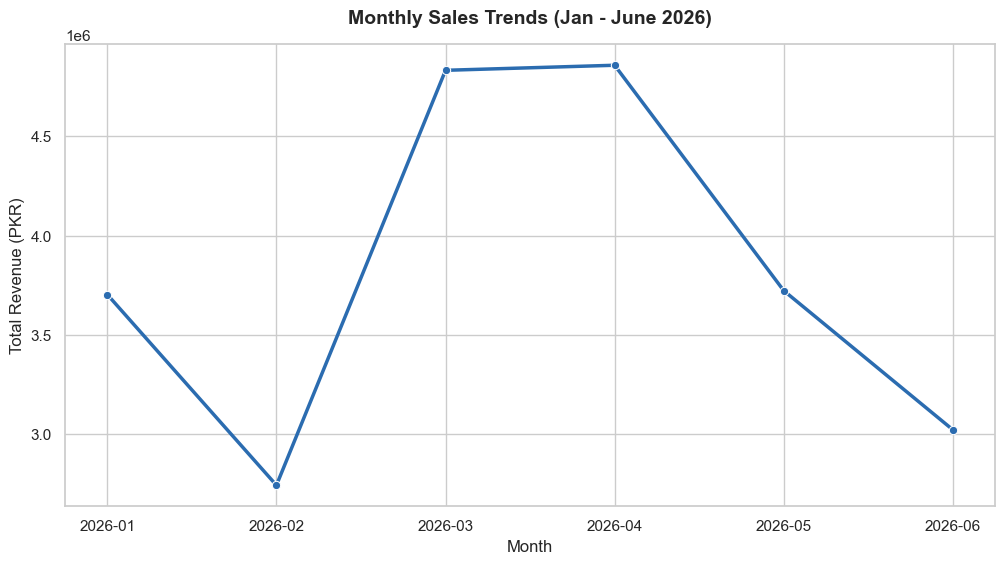

C:\Users\My Pc\AppData\Local\Temp\ipykernel_29976\4274039634.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Total Amount', y='Product Category', palette='Blues_r')


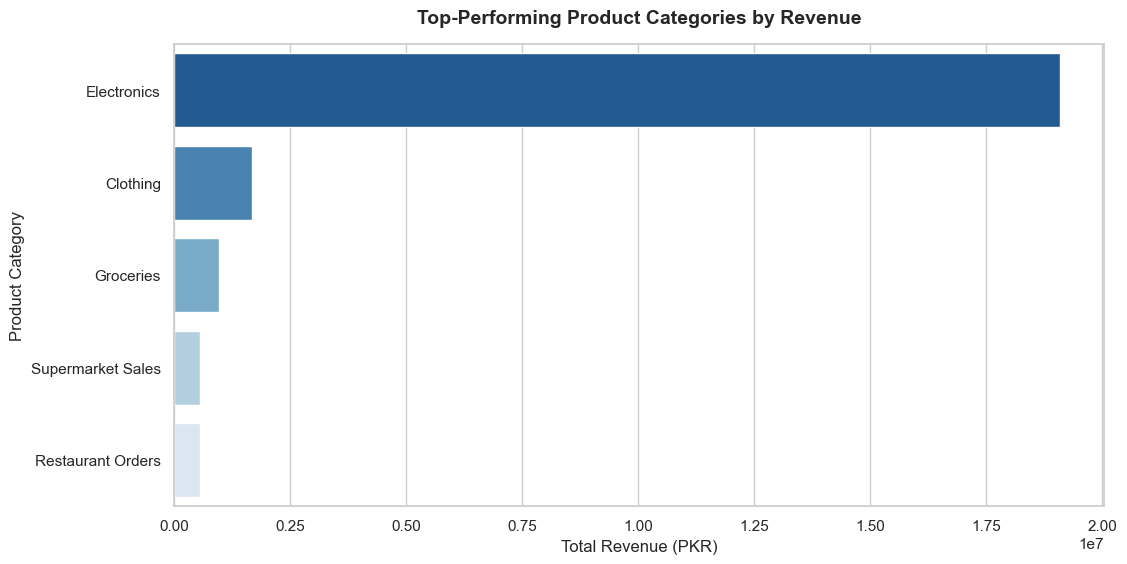

C:\Users\My Pc\AppData\Local\Temp\ipykernel_29976\4274039634.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_sales, x='Customer City', y='Total Amount', palette='Greens_r')


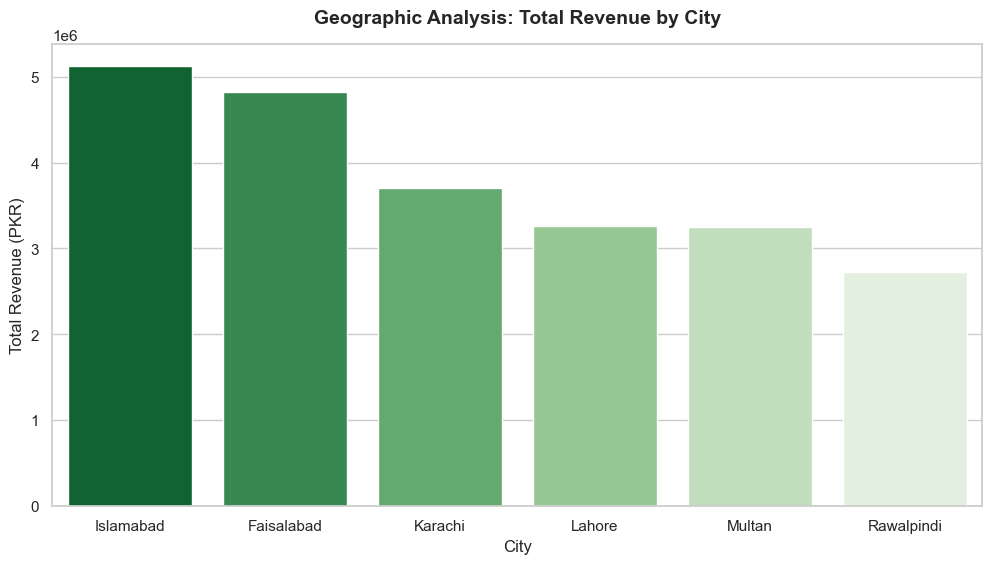

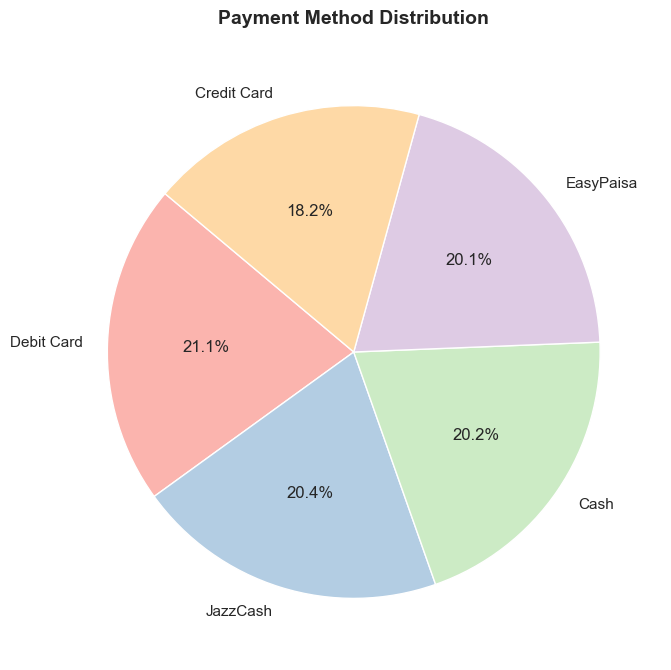

✅ Saare important EDA charts successfully generate aur save ho gaye hain!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Design theme set karte hain
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Monthly Sales Trends
df['Month'] = df['Purchase Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

plt.figure()
sns.lineplot(data=monthly_sales, x='Month', y='Total Amount', marker='o', linewidth=2.5, color='#2B6CB0')
plt.title('Monthly Sales Trends (Jan - June 2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (PKR)', fontsize=12)
plt.savefig('1_monthly_sales_trends.png', bbox_inches='tight')
plt.show()

# 2. Top-Performing Categories (Revenue by Category)
category_sales = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).reset_index()

plt.figure()
sns.barplot(data=category_sales, x='Total Amount', y='Product Category', palette='Blues_r')
plt.title('Top-Performing Product Categories by Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (PKR)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.savefig('2_category_performance.png', bbox_inches='tight')
plt.show()

# 3. Revenue by City
city_sales = df.groupby('Customer City')['Total Amount'].sum().sort_values(ascending=False).reset_index()

plt.figure()
sns.barplot(data=city_sales, x='Customer City', y='Total Amount', palette='Greens_r')
plt.title('Geographic Analysis: Total Revenue by City', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Revenue (PKR)', fontsize=12)
plt.savefig('3_revenue_by_city.png', bbox_inches='tight')
plt.show()

# 4. Payment Method Distribution
plt.figure(figsize=(8, 8))
payment_counts = df['Payment Method'].value_counts()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Pastel1'), startangle=140)
plt.title('Payment Method Distribution', fontsize=14, fontweight='bold', pad=15)
plt.savefig('4_payment_method_distribution.png', bbox_inches='tight')
plt.show()

print("✅ Saare important EDA charts successfully generate aur save ho gaye hain!")